1. What is the approximate depth of a decision tree trained (without restrictions)
on a training set with one million instances?

- depth≈log2​(N)  => 20  до 25 

2. Is a node’s Gini impurity generally lower or higher than its parent’s? Is it generally
lower/higher, or always lower/higher?

- Gini impurity на наследника обикновено е по малко от това на родителя му, но това не е задължително защото алгоритъма търси такъв сплит който като цяло да намал грешката на кост функцията но това не означава че индивидуално двете деца ще са с по малко замърсяване

3. If a decision tree is overfitting the training set, is it a good idea to try decreasing
max_depth?

- Да, намалянето на max_depth обикновено би намалило overfitting

4. If a decision tree is underfitting the training set, is it a good idea to try scaling the
input features?

- Скалирането на данните не би помогнало на decision tree да намали underfitting защото диапазона на данните не му влияе по никакъв начин

5. If it takes one hour to train a decision tree on a training set containing one
million instances, roughly how much time will it take to train another decision
tree on a training set containing ten million instances? Hint: consider the CART
algorithm’s computational complexity.

- Времевата сложност на CART алгоритъма за обучение на decision tree е O(n × m log2(m)) където n e броя на семплите а m е броя на характеристиките (10 000 000 * 2 log2(2)) / (1 000 000 * 2 log2(2)) = 10 тоес би отнело 10 часа

6. If it takes one hour to train a decision tree on a given training set, roughly how
much time will it take if you double the number of features?

- Времето расте линейно с броя на feature-ите. Удвояването на броя feature-и ще удвои времето, тоест би отнело 2 часа.

7. Train and fine-tune a decision tree for the moons dataset by following these
steps:
- a. Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset.
- b. Use train_test_split() to split the dataset into a training set and a test set.
- c. Use grid search with cross-validation (with the help of the GridSearchCV
class) to find good hyperparameter values for a DecisionTreeClassifier.
Hint: try various values for max_leaf_nodes.
- d. Train it on the full training set using these hyperparameters, and measure
your model’s performance on the test set. You should get roughly 85% to 87%
accuracy.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_moons(n_samples=10_000, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, shuffle=True)

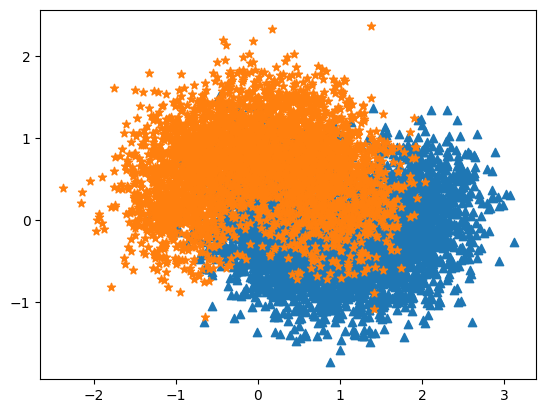

In [3]:
pos_class = y_train.astype(bool)
plt.scatter(X_train[pos_class, 0], X_train[pos_class, 1], marker='^')
neg_class = ~pos_class
plt.scatter(X_train[neg_class, 0], X_train[neg_class, 1], marker='*')
plt.show()

In [64]:
# grid = {
#     'max_depth': [3, 6, 7, 8, 10, None],
#     'max_leaf_nodes': [10, 15, 18, 20, 22],
#     'min_samples_leaf': [100, 200, 300, 500]
# }

params = {
    'max_leaf_nodes': [10, 15, 20, 25, 30, 50],
    'max_depth': [3, 6, 7, 8, 10, None],
    'min_samples_split': [2, 3, 4]
}

tree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(tree, params, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 6, ...], 'max_leaf_nodes': [10, 15, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [65]:
data = pd.DataFrame(grid_search.cv_results_)
params = pd.DataFrame(data['params'].to_list())
scores = data[['mean_test_score']]
results = pd.concat([params, scores], axis=1).sort_values('mean_test_score', ascending=False)
results.head()

,max_depth,max_leaf_nodes,min_samples_split,mean_test_score
100,NaN,25,3,0.8604
101,NaN,25,4,0.8604
81,10.0,25,2,0.8604
99,NaN,25,2,0.8604
82,10.0,25,3,0.8604


In [66]:
best_tree = DecisionTreeClassifier(random_state=42, **grid_search.best_params_)
best_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,25
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
y_test_pred = best_tree.predict(X_test)
best_tree_score = accuracy_score(y_test, y_test_pred)
best_tree_score

0.8628

8. Grow a forest by following these steps:
- a. Continuing the previous exercise, generate 1,000 subsets of the training set,
each containing 100 instances selected randomly. Hint: you can use Scikit-
Learn’s ShuffleSplit class for this.
- b. Train one decision tree on each subset, using the best hyperparameter values
found in the previous exercise. Evaluate these 1,000 decision trees on the test
set. Since they were trained on smaller sets, these decision trees will likely
perform worse than the first decision tree, achieving only about 80% accuracy.
- c. Now comes the magic. For each test set instance, generate the predictions of
the 1,000 decision trees, and keep only the most frequent prediction (you can
use SciPy’s mode() function for this). This approach gives you majority-vote
predictions over the test set.
- d. Evaluate these predictions on the test set: you should obtain a slightly higher
accuracy than your first model (about 0.5 to 1.5% higher). Congratulations,
you have trained a random forest classifier!

In [68]:
from sklearn.model_selection import ShuffleSplit
from scipy.stats import mode

In [69]:
train_splits_inxs = []

for inxs, _ in ShuffleSplit(1_000, train_size=100, test_size=None, random_state=42).split(X_train):
    train_splits_inxs.append(inxs)

In [70]:
trees = []
n_trees = len(train_splits_inxs)
scores = np.empty(n_trees)
tree_predictions = np.empty((n_trees, len(y_test)), dtype=y_test.dtype)

for i, inxs in enumerate(train_splits_inxs):
    X_train_mini, y_train_mini = X_train[inxs], y_train[inxs]

    tree = DecisionTreeClassifier(random_state=42, **grid_search.best_params_)
    tree.fit(X_train_mini, y_train_mini)
    trees.append(tree)

    y_test_pred = tree.predict(X_test)
    tree_predictions[i] = y_test_pred
    scores[i] = accuracy_score(y_test, y_test_pred)

scores.mean()

np.float64(0.7901284000000001)

In [71]:
results, count = mode(tree_predictions, axis=0)
forest_score = accuracy_score(y_test, results)
forest_score

0.8624

**Task 3**
за последните няколко задачи където обучнието е продължаило повече от 1 мин - да се записват обучените модели и при тестване да се заржда готовия модел, за да не се налага при генериране на резултатите всеки път да се чака обучението.

In [45]:
import joblib
joblib.dump(best_tree, 'best_tree_ch6.pkl')

['best_tree_ch6.pkl']

In [46]:
load_best_tree = joblib.load('best_tree_ch6.pkl')

y_test_pred = load_best_tree.predict(X_test)
best_tree_score = accuracy_score(y_test, y_test_pred)
best_tree_score

0.864

In [47]:
joblib.dump(trees, 'custom_forest_ch6.pkl')

['custom_forest_ch6.pkl']

In [48]:
custom_forest = joblib.load('custom_forest_ch6.pkl')

tree_predictions = np.array([tree.predict(X_test) for tree in custom_forest])

results, count = mode(tree_predictions, axis=0)
forest_score = accuracy_score(y_test, results)
forest_score

0.5

**Task 4**
да се разработи клас който работи като класификатор, който вътрешно ползва decision tree при обучението. след като е обучен взема описанието на дървото от атрибут tree_ на полученото дърво и при прогноза директно навигира дървото и определя резултата.

In [17]:
from sklearn.datasets import load_iris
from sklearn.base import check_is_fitted, check_array
from graphviz import Source
from sklearn.tree import DecisionTreeClassifier

In [18]:
iris = load_iris(as_frame=True)

X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
print(tree_clf.tree_.children_left)
print(tree_clf.tree_.children_right)
print(tree_clf.tree_.feature)
print(tree_clf.tree_.threshold)
print('impurity:', tree_clf.tree_.impurity)
print('n_node_samples:', tree_clf.tree_.n_node_samples) 
print('n_classes:', tree_clf.tree_.n_classes) 
print('weighted_n_node_samples:', tree_clf.tree_.weighted_n_node_samples) 
print(tree_clf.tree_.value)

[ 1 -1  3  4 -1 -1  7 -1 -1]
[ 2 -1  6  5 -1 -1  8 -1 -1]
[ 0 -2  1  0 -2 -2  0 -2 -2]
[ 2.44999999 -2.          1.75        4.95000005 -2.         -2.
  4.85000014 -2.         -2.        ]
impurity: [0.66666667 0.         0.5        0.16803841 0.04079861 0.44444444
 0.04253308 0.44444444 0.        ]
n_node_samples: [150  50 100  54  48   6  46   3  43]
n_classes: [3]
weighted_n_node_samples: [150.  50. 100.  54.  48.   6.  46.   3.  43.]
[[[0.33333333 0.33333333 0.33333333]]

 [[1.         0.         0.        ]]

 [[0.         0.5        0.5       ]]

 [[0.         0.90740741 0.09259259]]

 [[0.         0.97916667 0.02083333]]

 [[0.         0.33333333 0.66666667]]

 [[0.         0.02173913 0.97826087]]

 [[0.         0.33333333 0.66666667]]

 [[0.         0.         1.        ]]]


In [46]:
from importlib import reload
import custom_decision_tree_clf
reload(custom_decision_tree_clf)
from sklearn.tree import export_graphviz


from custom_decision_tree_clf import DecisionTreeClassifier
custom_tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
custom_tree_clf.fit(X_iris, y_iris)

export_graphviz(
    custom_tree_clf,
    out_file="custom_tree_depth2.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

print(custom_tree_clf.tree_.children_left)
print(custom_tree_clf.tree_.children_right)
print(custom_tree_clf.tree_.feature)
print(custom_tree_clf.tree_.threshold)
print(custom_tree_clf.tree_.value)

[np.float64(0.6666666666666665), np.float64(0.0), np.float64(0.5), np.float64(0.1680384087791495), np.float64(0.04253308128544431)]
[1, -1, 3, -1, -1]
[2, -1, 4, -1, -1]
[np.int64(0), -2, np.int64(1), -2, -2]
[np.float64(1.9), -2, np.float64(1.7), -2, -2]
[[[0.33333333 0.33333333 0.33333333]]

 [[1.         0.         0.        ]]

 [[0.         0.5        0.5       ]]

 [[0.         0.90740741 0.09259259]]

 [[0.         0.02173913 0.97826087]]]


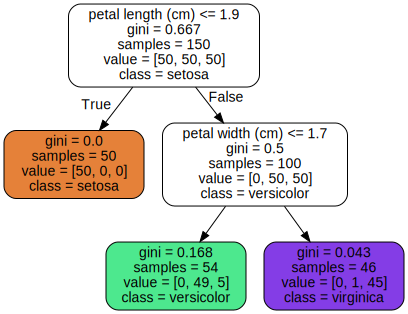

In [47]:
Source.from_file("custom_tree_depth2.dot")

In [21]:
print('Custom:', accuracy_score(y_iris, custom_tree_clf.predict(X_iris)))
print('Org:', accuracy_score(y_iris, tree_clf.predict(X_iris)))

Custom: 0.96
Org: 0.96


In [68]:
print('----- Custom -----')
from importlib import reload
import custom_decision_tree_clf
reload(custom_decision_tree_clf)

from custom_decision_tree_clf import DecisionTreeClassifier
custom_tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, splitter='random')
custom_tree_clf.fit(X_iris, y_iris)
print('left ch:', custom_tree_clf.tree_.children_left)
print('right ch:', custom_tree_clf.tree_.children_right)
print('features:', custom_tree_clf.tree_.feature)
print('thresholds:', custom_tree_clf.tree_.threshold)
print('impurity:', custom_tree_clf.tree_.impurity)
print('values:')
print(custom_tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, custom_tree_clf.predict(X_iris)))

export_graphviz(
    custom_tree_clf,
    out_file="custom_tree_depth3.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

print('----- Org -----')
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, splitter='random')
tree_clf.fit(X_iris, y_iris)
print('left ch:', tree_clf.tree_.children_left)
print('right ch:', tree_clf.tree_.children_right)
print('features:', tree_clf.tree_.feature)
print('thresholds:', tree_clf.tree_.threshold)
print('impurity:', tree_clf.tree_.impurity)
print('values:')
print(tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, tree_clf.predict(X_iris)))

export_graphviz(
    tree_clf,
    out_file="org_tree_depth3.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)


----- Custom -----
left ch: [1, -1, 3, -1, -1]
right ch: [2, -1, 4, -1, -1]
features: [np.int64(0), -2, np.int64(0), -2, -2]
thresholds: [np.float64(2.0822652602103666), -2, np.float64(5.334768088368443), -2, -2]
impurity: [np.float64(0.6666666666666665), np.float64(0.0), np.float64(0.5), np.float64(0.40816326530612246), np.float64(0.0)]
values:
[array([[0.33333333, 0.33333333, 0.33333333]]), array([[1., 0., 0.]]), array([[0. , 0.5, 0.5]]), array([[0.        , 0.71428571, 0.28571429]]), array([[0., 0., 1.]])]
ACC: 0.8666666666666667
----- Org -----
left ch: [ 1 -1  3  4 -1 -1 -1]
right ch: [ 2 -1  6  5 -1 -1 -1]
features: [ 1 -2  0  1 -2 -2 -2]
thresholds: [ 0.57149852 -2.          5.57477882  1.90954018 -2.         -2.
 -2.        ]
impurity: [0.66666667 0.         0.50975395 0.45879501 0.3616568  0.
 0.        ]
values:
[[[0.33333333 0.33333333 0.33333333]]

 [[1.         0.         0.        ]]

 [[0.00990099 0.4950495  0.4950495 ]]

 [[0.01315789 0.65789474 0.32894737]]

 [[0.01538

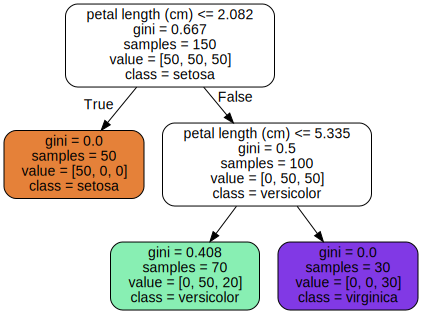

In [69]:
Source.from_file("custom_tree_depth3.dot")

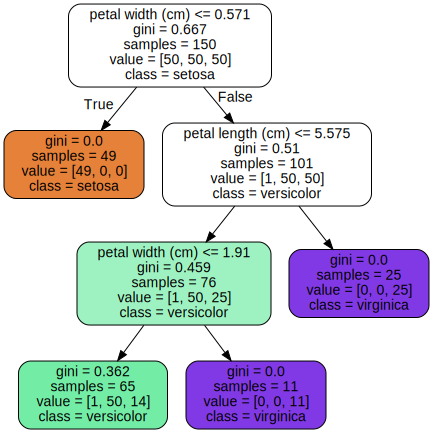

In [70]:
Source.from_file("org_tree_depth3.dot")

In [53]:
class CustomDecisionTree:
    def __init__(self, **params):
        self.params = params 

    def fit(self, X, y):
        self.tree_ = DecisionTreeClassifier(**self.params).fit(X, y).tree_

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        
        children_left = self.tree_.children_left
        children_right = self.tree_.children_right
        feature = self.tree_.feature
        threshold = self.tree_.threshold
        values = self.tree_.value

        predictions = np.empty(X.shape[0], dtype=int)
        for i, sample in enumerate(X):
            node = 0
            while True:
                f_i = feature[node]
                t = threshold[node]

                if f_i == -2:
                    predictions[i] = values[node].argmax()
                    break
                
                f = sample[f_i]
                if f <= t:
                    node = children_left[node]
                else:
                    node = children_right[node]

        return predictions 

In [54]:
print('----------- CustomDecisionTree -----------')
custom_tree = CustomDecisionTree(max_depth=2, random_state=42)
custom_tree.fit(X_iris, y_iris)
y_iris_pred = custom_tree.predict(X_iris)
custom_tree_acc = accuracy_score(y_iris, y_iris_pred)
print(custom_tree_acc)

print('----------- OriginalDecisionTree -----------')
y_iris_pred = tree_clf.predict(X_iris)
org_tree_acc = accuracy_score(y_iris, y_iris_pred)
print(org_tree_acc)

----------- CustomDecisionTree -----------
0.96
----------- OriginalDecisionTree -----------
0.96
